In [81]:
import geopandas as gpd
from shapely import Polygon
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd

In [ ]:
brno_b_point = r"data\brno_build_points.geojson"
grid = r"data\brno_grid.shp" # 1km*1km
brno_outline = r"data\Brno_outline.shp"
brno_floor = r"data\brno_buildings.geojson"
b_outline = gpd.read_file(brno_outline)
b_point = gpd.read_file(brno_b_point )
b_grid = gpd.read_file(grid)
b_floor = gpd.read_file(brno_floor)

In [117]:
floors = b_floor.loc[:,'np1_1f':'np28_1f1']

In [175]:
floors[98024:98025]

,np1_1f,np1_1f_rel,np1_2f,np1_2f_rel,np1_3f,np1_3f_rel,np1_4f,np1_4f_rel,np1_5f,np1_5f_rel,...,np19_1f1,np20_1f1,np21_1f1,np22_1f1,np23_1f1,np24_1f1,np25_1f1,np26_1f1,np27_1f1,np28_1f1
98024,maloobchod,60,služby spotřebitelské,40,,0,,0,,0,...,kanceláře,kanceláře,kanceláře,kanceláře,bydlení,bydlení,bydlení,bydlení,bydlení,bydlení


In [168]:
def row_to_dict(row):
    result = {}
    for col in row.index:
        if col.endswith('_rel'):
            continue

        label = row[col]
        if (pd.isna(label)) or (label.strip() == ''):
            continue
        
        rel_col = f'{col}_rel'
        value = row[rel_col] if rel_col in row.index and pd.notna(row[rel_col]) else 100

        result[label] = result.get(label, 0) + int(float(value))

    return result

dict_series = floors.apply(row_to_dict, axis=1)

In [169]:
df = pd.DataFrame.from_records(dict_series, index=dict_series.index).fillna(0)
df['Non_residential'] = df.drop(columns=['bydlení']).sum(axis=1)
b_floor[['Non_residential','bydlení']] = df[['Non_residential','bydlení']]

In [ ]:
# from 2:00 to 23:00
resident_prop = np.array([1.0,1.0,1.0,1.0,0.98,0.95,0.90,0.60,0.3,0.25,0.25,0.25,0.25,0.30,0.35,0.40,0.50,0.60,0.70,0.75,0.85,0.90])

In [107]:
# Random generating non-residential area proportions in each grid.
rng = np.random.default_rng(42)
non_residential = rng.random(289)
non_prop = non_residential/non_residential.sum()

In [179]:
grid_clip = b_grid[b_grid.intersects(b_outline.geometry[0])]

In [ ]:

grid_pop = grid_clip.sjoin(b_point,'left','contains').groupby(level=0)['budobyev'].sum()
grid_clip['resident_num'] = grid_pop
resident = grid_clip['resident_num'].to_numpy()
resident_dynamic = np.tile(resident_prop,(289,1)) * resident[:,np.newaxis]

NameError: name 'resident_prop' is not defined

In [182]:
b_floor = b_floor.to_crs('EPSG:5514')
overlay = gpd.overlay(grid_clip,b_floor,'intersection')

In [189]:
overlay['area']=overlay.area

In [191]:
overlay.sort_values('area',inplace=True)

In [193]:
overlay.drop_duplicates(subset='grid_id', keep='last', inplace=True)

In [197]:
overlay

,grid_id,objectid,join_count,target_fid,fid_bld,fid_bld_part,kod_ruian,npodl,strpodl,strecha_vyuziti,...,np27_1f1,np28_1f1,strecha,globalid,shape_Length,shape_Area,Non_residential,bydlení,geometry,area
14864,173,93168,1,93192,29544,25195,1000027881,1,0,ne,...,,,rovná střecha,{48B23334-5D6B-4A14-A769-EA9450F576BC},0.000157,1.400742e-09,100.0,0.0,"POLYGON ((-602252.339 -1164782.546, -602252.43...",11.361143
2979,103,36133,1,36149,91313,58657,1000010978,1,0,ne,...,,,rovná střecha,{C499B6E4-BEE6-44CF-8C23-574036D48B69},0.000225,2.486252e-09,100.0,0.0,"POLYGON ((-606142.951 -1151046.426, -606148.90...",20.117482
117728,357,27644,1,27656,56084,41778,1000005550,1,0,ne,...,,,rovná střecha,{FFB9C237-103B-4EDF-95F0-C750CA44C83B},0.000218,2.833067e-09,100.0,0.0,"POLYGON ((-593910.142 -1169517.124, -593914.88...",22.994157
130787,453,53846,1,53862,5765,5652,19254997,1,0,ne,...,,,rovná střecha,{FF9E05C2-3BD9-4EE0-B146-FD7F8620AEB1},0.000259,3.439887e-09,100.0,0.0,"POLYGON ((-589912.081 -1157601.304, -589913.61...",27.857719
27847,215,1773,1,1773,84549,98381,1000000127,2,1,ne,...,,,šikmá střecha,{82D41DEA-0573-4478-A309-CAD1D04BA88A},0.000267,4.341634e-09,200.0,0.0,"POLYGON ((-600670.699 -1164453.856, -600670.87...",35.210949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112846,342,16663,1,16666,40737,32613,51162504,3,0,ne,...,,,rovná střecha,{344EDC6B-7D25-4944-A0A5-BC3A6525AAF9},0.008165,3.016868e-06,300.0,0.0,"POLYGON ((-594085.094 -1163375.4, -594061.809 ...",22665.270279
117987,362,103559,2,103584,87978,99683,27048161,2,0,ne,...,,,rovná střecha,{73773956-281C-421E-B3A3-8720BA49261E},0.008750,3.034635e-06,200.0,0.0,"POLYGON ((-593759.085 -1164427.086, -593755.28...",24607.818959
121783,382,102868,1,102893,89208,72417,96120771,2,0,ne,...,,,rovná střecha,{EAF379C2-7144-46EC-B6D2-2B18526B08FA},0.010904,3.149392e-06,200.0,0.0,"POLYGON ((-592231.418 -1165668.024, -592266.87...",25543.096351
120224,366,59712,2,59729,48119,108666,48907375,3,1,ne,...,,,kombinace,{9BBE3E20-2A24-4A53-8142-171D766E6003},0.008865,3.662297e-06,300.0,0.0,"POLYGON ((-593315.919 -1161007.314, -593315.14...",29679.415376


In [121]:
non_re_dynamic = abs(np.sum(resident_dynamic,axis=0) - 359194) * non_prop[:,np.newaxis]

In [124]:
grid_dynamic = resident_dynamic+non_re_dynamic

In [125]:
for i in range(22):
    key = str(i+2)
    grid_clip[key] = grid_dynamic[:,i]

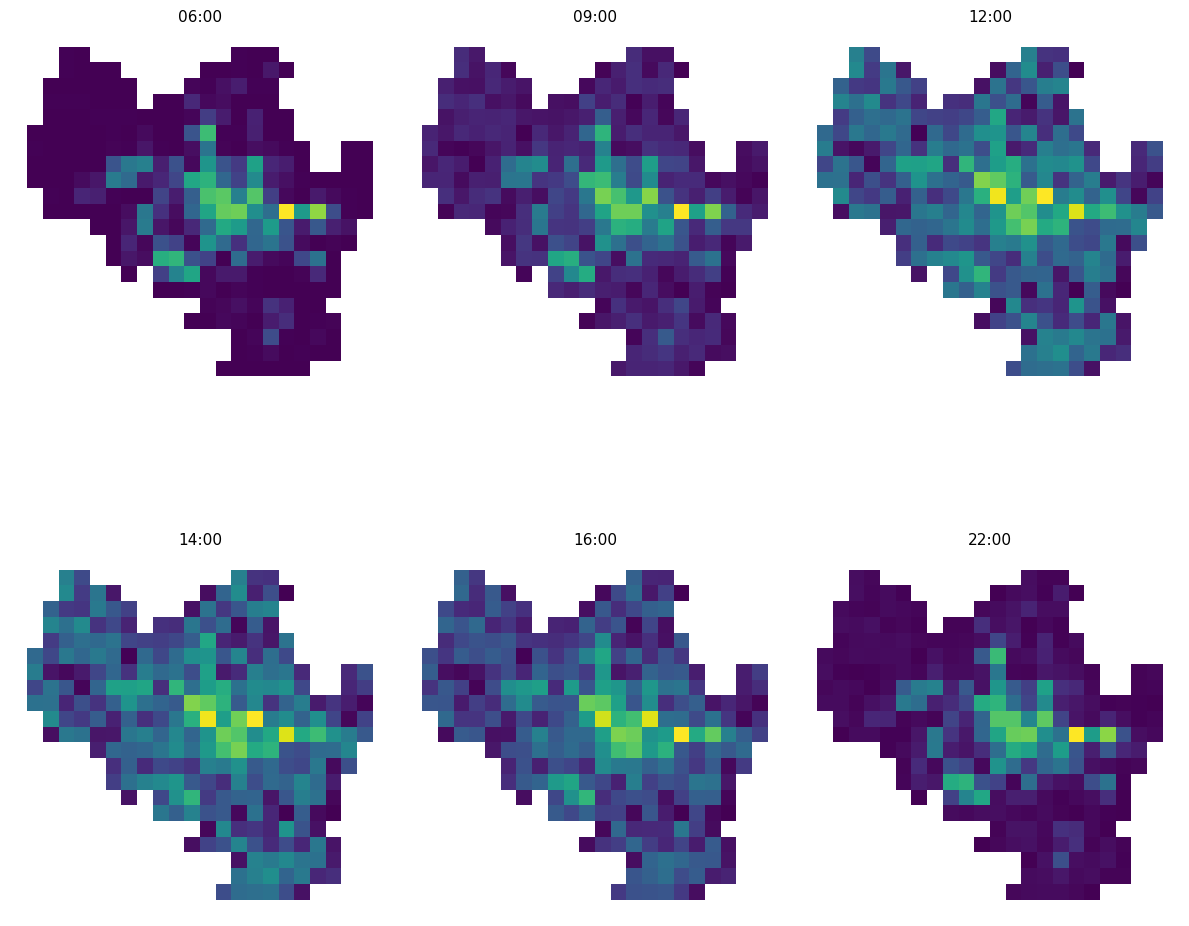

In [138]:
fig, ax = plt.subplots(2, 3, figsize=(12, 12))

cols = ['6', '9', '12', '14', '16', '22']
titles = ['06:00', '09:00', '12:00', '14:00', '16:00', '22:00']
vmin = min(grid_clip[c].min() for c in cols)
vmax = max(grid_clip[c].max() for c in cols)

cmap = "viridis"
for a, c, t in zip(ax.flat, cols, titles):
    grid_clip.plot(
        column=c,
        ax=a,
    )
    a.set_title(t, fontsize=11)  # label
    a.set_axis_off()             # hide axis outline/ticks
    

plt.tight_layout()
plt.show()